# **Sleep Spindle Detection Machine Learning Model Pipeline On DREAM Dataset**

---



---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. LIBRARY IMPORTS & SETUP

- Imports essential libraries for signal processing (scipy, mne)
- Sets up machine learning environment (sklearn, imblearn)
- Configures visualization settings (matplotlib)
- Defines constants for signal processing (sampling frequency, window sizes)

**Why**: Creates foundation for all processing, ensuring consistent parameters across pipeline and reproducible results.

In [19]:
from pathlib import Path
import mne, pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             confusion_matrix, precision_recall_curve,
                             classification_report, roc_curve)
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from scipy.stats import entropy
from mne.time_frequency import psd_array_welch

plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
mne.set_log_level('ERROR')

In [20]:
DATA_DIR = Path(r"/content/drive/MyDrive/DREAM_Database_Spindles")
WINDOW_SEC = 0.5
STRIDE_SEC = 0.4
TARGET_SFREQ = 128
SPINDLE_BAND = (11, 16)

EEG_PREFERENCES = ['C3-A1', 'CZ-A1', 'Cz-A1',
                   'EEG C3-A1', 'EEG CZ-A1',
                   'C3', 'CZ', 'Cz']

print(f"📊 Configuration:")
print(f"- Data directory: {DATA_DIR}")
print(f"- Window size: {WINDOW_SEC}s with {STRIDE_SEC}s stride")
print(f"- Target sampling frequency: {TARGET_SFREQ} Hz")
print(f"- Spindle band: {SPINDLE_BAND} Hz")

📊 Configuration:
- Data directory: /content/drive/MyDrive/DREAM_Database_Spindles
- Window size: 0.5s with 0.4s stride
- Target sampling frequency: 128 Hz
- Spindle band: (11, 16) Hz


## 2. DATA LOADING

- Loads EEG excerpts from DREAM Database
- Extracts spindle annotations from files
- Handles missing data or format inconsistencies
- Provides uniform access to different excerpts

**Why**: Standardized data loading ensures consistent formats and error handling across different recording segments.

In [21]:
def load(idx):
    edf = DATA_DIR / f"excerpt{idx}.edf"
    ann1 = DATA_DIR / f"Visual_scoring1_excerpt{idx}.txt"
    ann2 = DATA_DIR / f"Visual_scoring2_excerpt{idx}.txt"

    raw = mne.io.read_raw_edf(edf, preload=True, verbose='ERROR')

    # Pick channel safely
    ch = next((c for c in EEG_PREFERENCES if c in raw.ch_names), raw.ch_names[0])
    raw.pick([ch])


    raw.filter(l_freq=SPINDLE_BAND[0], h_freq=SPINDLE_BAND[1], verbose='ERROR')
    raw.resample(TARGET_SFREQ, verbose='ERROR')
    data = raw.get_data()[0]
    sf = raw.info["sfreq"]

    # Load annotations
    a1 = pd.read_csv(ann1, sep=r'\s+', header=None,
                     names=["start", "dur"], comment='[').astype(float).values
    if ann2.exists():
        a2 = pd.read_csv(ann2, sep=r'\s+', header=None,
                         names=["start", "dur"], comment='[').astype(float).values
    else:
        a2 = a1.copy()
    anns = np.vstack([a1, a2])
    return data, anns, sf, ch


## 3. SIGNAL PREPROCESSING AND VISUALIZZATION

- Prepares signals for consistent feature extraction
- Displays EEG signals with annotated spindles
- Provides statistical summaries of signals
- Enables visual inspection of data quality


**Why**: Visual verification ensures annotations match actual spindle events and helps identify potential data issues.

*   List item
*   List item



DREAM Dataset Summary:


,Excerpt,Channel,Duration (sec),Spindles,Spindles/min
0,1,C3-A1,1800.0,167,5.566667
1,2,CZ-A1,1800.0,112,3.733333
2,3,C3-A1,1800.0,49,1.633333
3,4,CZ-A1,1800.0,69,2.300000
4,5,CZ-A1,1800.0,142,4.733333
5,6,CZ-A1,1800.0,159,5.300000
6,7,CZ-A1,1800.0,36,1.200000


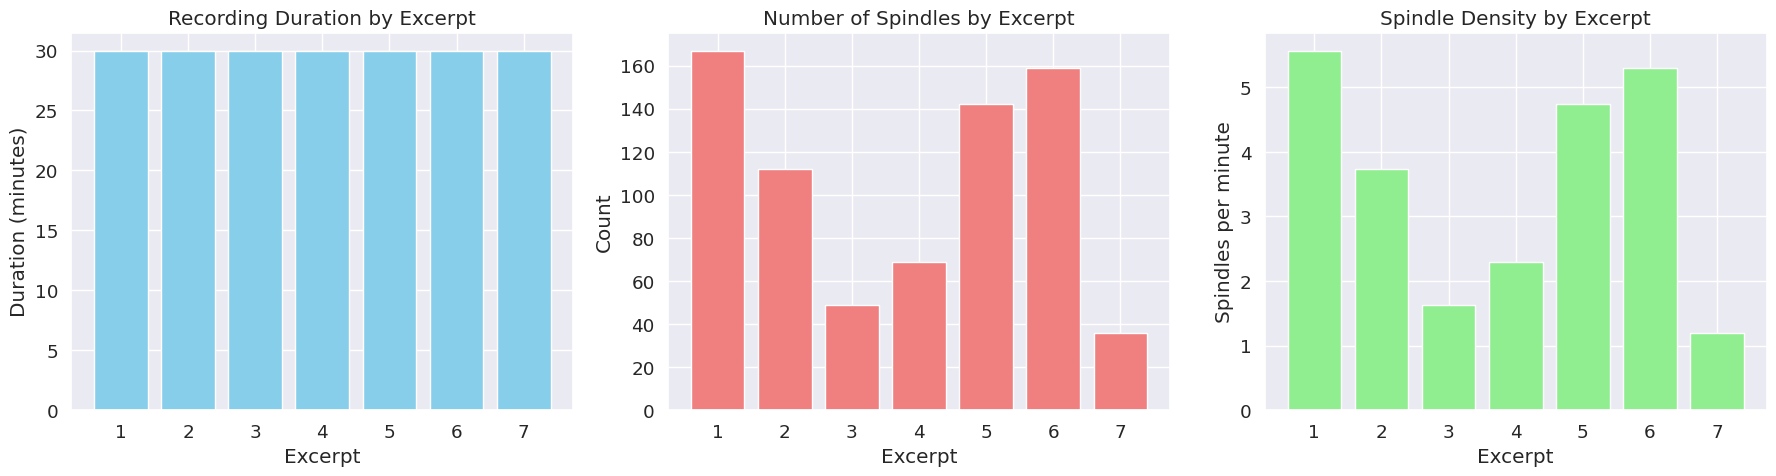

In [22]:
excerpts_info = []

for idx in range(1, 8):
    try:
        edf_file = DATA_DIR / f"excerpt{idx}.edf"
        if not edf_file.exists():
            continue

        data, anns, sf, ch = load(idx)
        duration = len(data) / sf

        excerpts_info.append({
            'Excerpt': idx,
            'Channel': ch,
            'Duration (sec)': duration,
            'Spindles': len(anns),
            'Spindles/min': len(anns) / (duration/60)
        })
    except Exception as e:
        print(f"Error loading excerpt {idx}: {e}")

if excerpts_info:
    dataset_info = pd.DataFrame(excerpts_info)
    print("DREAM Dataset Summary:")
    display(dataset_info)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Recording durations
    axes[0].bar(dataset_info['Excerpt'], dataset_info['Duration (sec)']/60, color='skyblue')
    axes[0].set_title('Recording Duration by Excerpt')
    axes[0].set_xlabel('Excerpt')
    axes[0].set_ylabel('Duration (minutes)')

    # 2. Number of spindles
    axes[1].bar(dataset_info['Excerpt'], dataset_info['Spindles'], color='lightcoral')
    axes[1].set_title('Number of Spindles by Excerpt')
    axes[1].set_xlabel('Excerpt')
    axes[1].set_ylabel('Count')

    # 3. Spindle density
    axes[2].bar(dataset_info['Excerpt'], dataset_info['Spindles/min'], color='lightgreen')
    axes[2].set_title('Spindle Density by Excerpt')
    axes[2].set_xlabel('Excerpt')
    axes[2].set_ylabel('Spindles per minute')

    plt.tight_layout()
    plt.show()
else:
    print("No excerpts found. Please check the DATA_DIR path.")

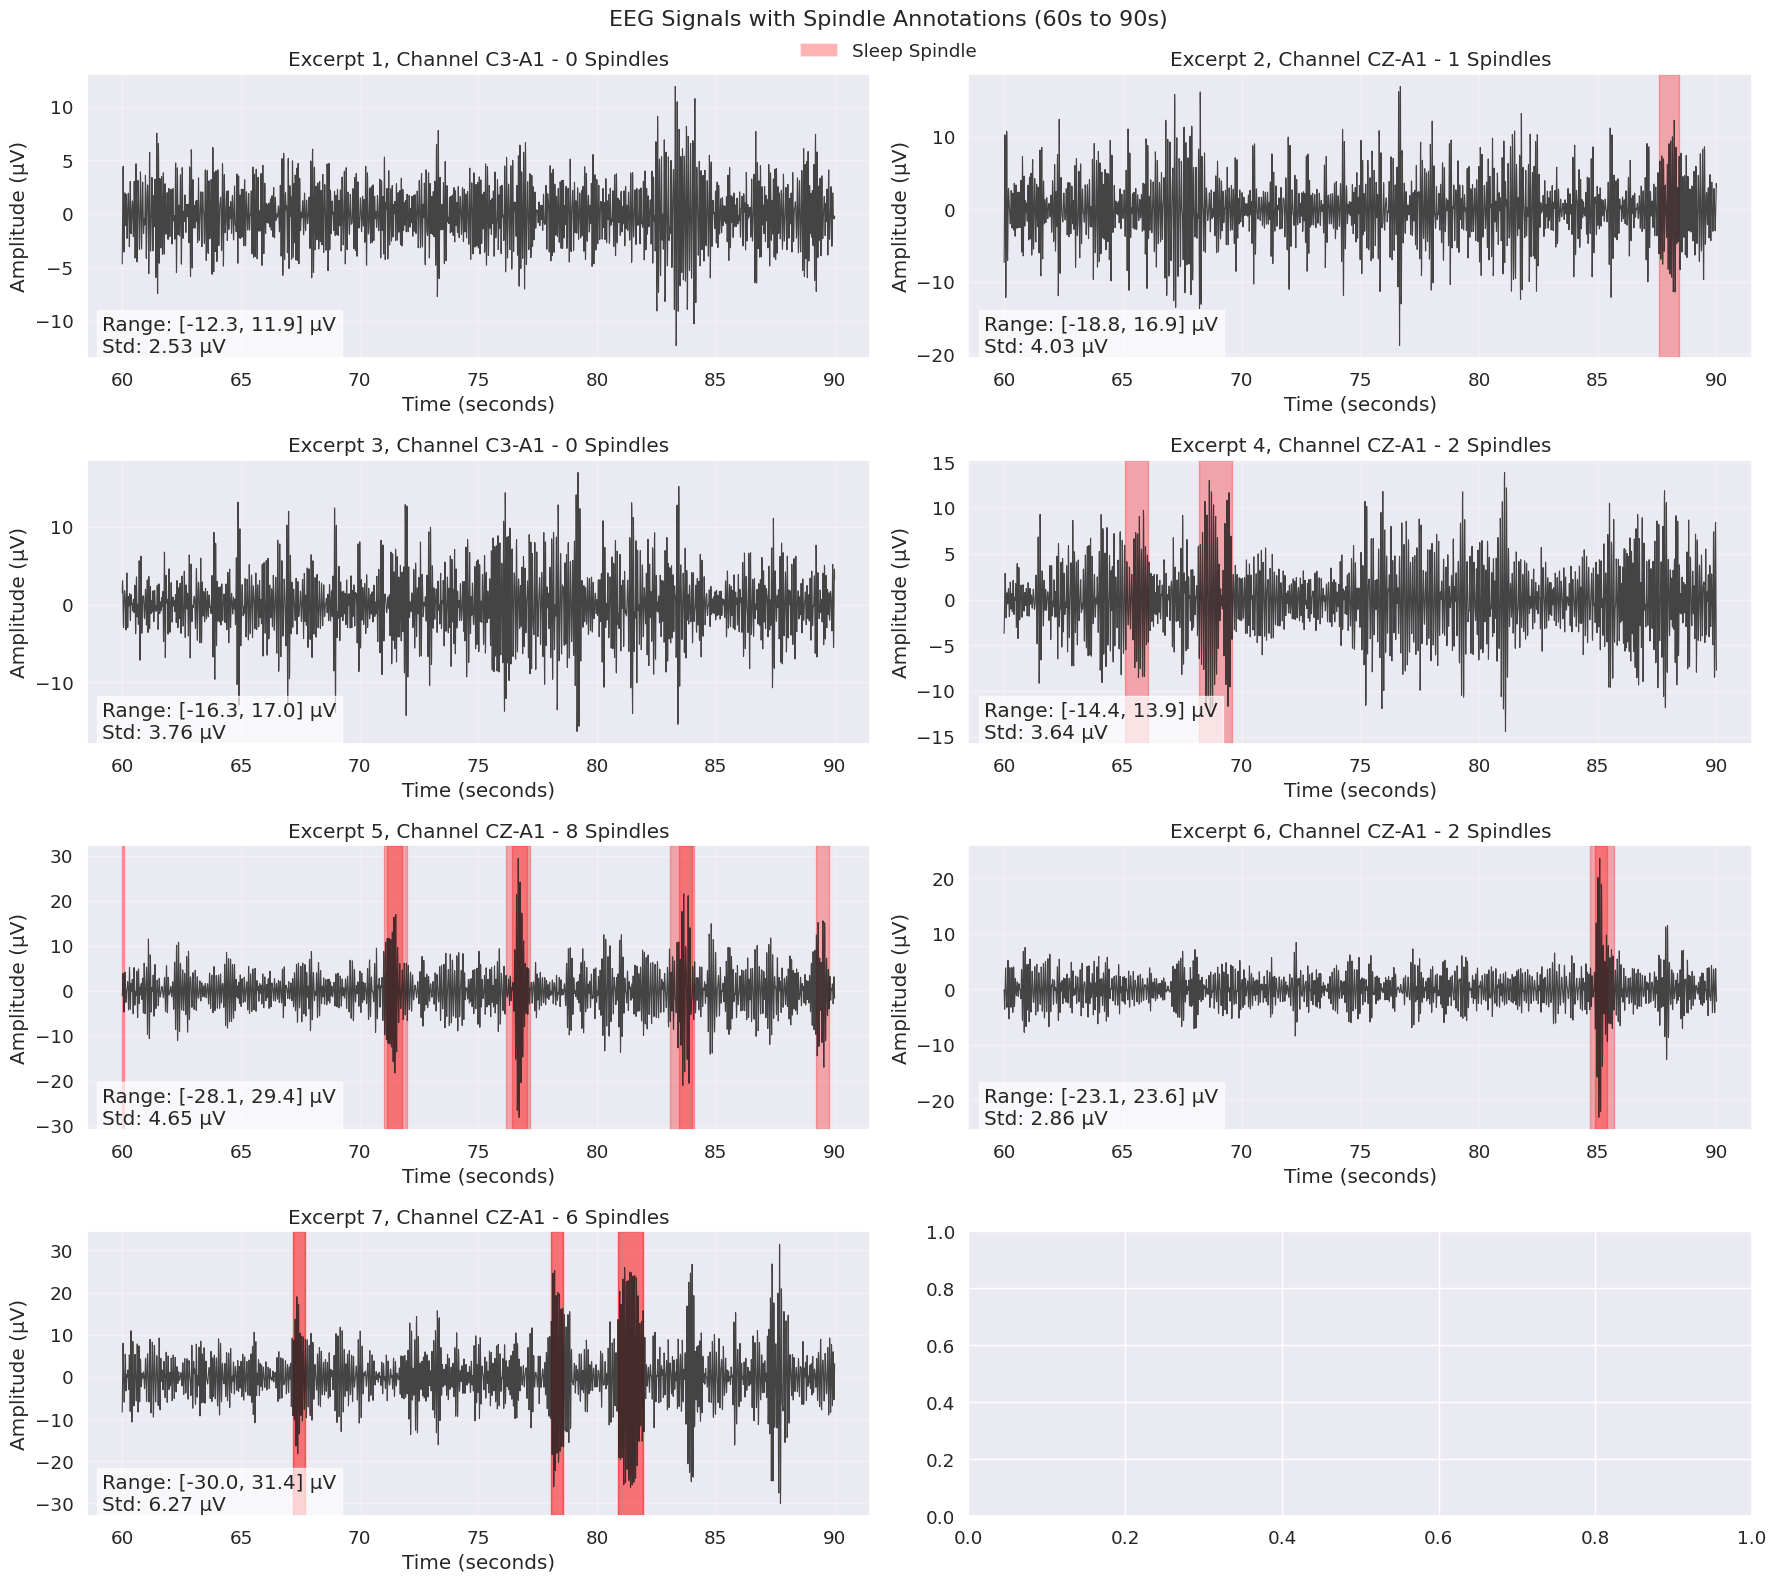

Successfully visualized 7 excerpts


In [23]:
def visualize_all_excerpts(start_sec=60, duration_sec=30):
    """
    Visualize EEG signals from all excerpts with spindle annotations in a single figure.

    Parameters:
    - start_sec: Start time in seconds for visualization
    - duration_sec: Duration to display in seconds
    """
    fig, axes = plt.subplots(4, 2, figsize=(18, 16))
    axes = axes.flatten()

    processed_count = 0

    for idx in range(1, 8):
        try:
            data, anns, sf, ch = load(idx)

            start_sample = int(start_sec * sf)
            end_sample = min(int((start_sec + duration_sec) * sf), len(data))

            # Extract segment
            segment = data[start_sample:end_sample]
            time = np.linspace(start_sec, start_sec + len(segment)/sf, len(segment))

            ax = axes[idx-1]
            ax.plot(time, segment, 'k-', linewidth=0.8, alpha=0.8)

            spindles_in_view = 0
            for start, dur in anns:
                if start < (start_sec + duration_sec) and (start + dur) > start_sec:
                    spindle_start = max(start, start_sec)
                    spindle_end = min(start + dur, start_sec + duration_sec)
                    ax.axvspan(spindle_start, spindle_end, color='red', alpha=0.3)
                    spindles_in_view += 1

            ax.set_title(f'Excerpt {idx}, Channel {ch} - {spindles_in_view} Spindles')
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Amplitude (μV)')
            ax.grid(True, alpha=0.3)

            stats_text = (f"Range: [{segment.min():.1f}, {segment.max():.1f}] μV\n"
                          f"Std: {segment.std():.2f} μV")
            ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
                   bbox=dict(facecolor='white', alpha=0.7))

            processed_count += 1

        except Exception as e:
            ax = axes[idx-1]
            ax.text(0.5, 0.5, f"Excerpt {idx} not available",
                   ha='center', va='center', fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            print(f"Error visualizing excerpt {idx}: {e}")

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.3, label='Sleep Spindle')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3)

    fig.suptitle(f"EEG Signals with Spindle Annotations ({start_sec}s to {start_sec+duration_sec}s)",
                fontsize=16, y=0.99)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

    print(f"Successfully visualized {processed_count} excerpts")


visualize_all_excerpts(start_sec=60, duration_sec=30)

## 4. WINDOWING

- Segments continuous EEG into fixed-length windows
- Assigns binary labels based on spindle overlap
- Implements class balancing through strategic sampling
- Creates discrete examples for machine learning

**Why**: Transforms continuous signals into a classification problem; balanced windowing addresses severe class imbalance.


In [24]:
def make_windows(data, anns, sf=256, win=WINDOW_SEC, stride=STRIDE_SEC):
    """
    Parameters:
    - data: EEG signal array
    - anns: Spindle annotations [start_time, duration]
    - sf: Sampling frequency
    - win: Window size in seconds
    - stride: Stride between consecutive windows in seconds

    Returns:
    - X: Window segments
    - y: Binary labels (1=spindle, 0=non-spindle)
    """
    win_s, stride_s = int(win*sf), int(stride*sf)
    starts = np.arange(0, len(data)-win_s+1, stride_s)
    X_all, y_all = [], []

    for s in starts:
        seg = data[s:s+win_s]

        seg_start, seg_end = s/sf, (s+win_s)/sf

        overlap = sum(max(0, min(seg_end, st+dur) - max(seg_start, st))
                      for st, dur in anns)

        label = 1 if overlap >= 0.5*win else 0

        X_all.append(seg)
        y_all.append(label)

    X_all = np.array(X_all)
    y_all = np.array(y_all)

    spindle_indices = np.where(y_all == 1)[0]
    nonspindle_indices = np.where(y_all == 0)[0]

    n_spindle = len(spindle_indices)
    n_nonspindle = len(nonspindle_indices)

    # Target a 1:3 ratio (spindle:non-spindle)
    n_nonspindle_keep = min(n_nonspindle, 3 * n_spindle)

    if n_nonspindle > n_nonspindle_keep:
        np.random.seed(42)
        nonspindle_keep_indices = np.random.choice(
            nonspindle_indices, n_nonspindle_keep, replace=False)
    else:
        nonspindle_keep_indices = nonspindle_indices
    keep_indices = np.concatenate([spindle_indices, nonspindle_keep_indices])
    X = X_all[keep_indices]
    y = y_all[keep_indices]

    print(f"Original: {n_spindle} spindle, {n_nonspindle} non-spindle windows")
    print(f"Balanced: {n_spindle} spindle, {n_nonspindle_keep} non-spindle windows")

    return X, y



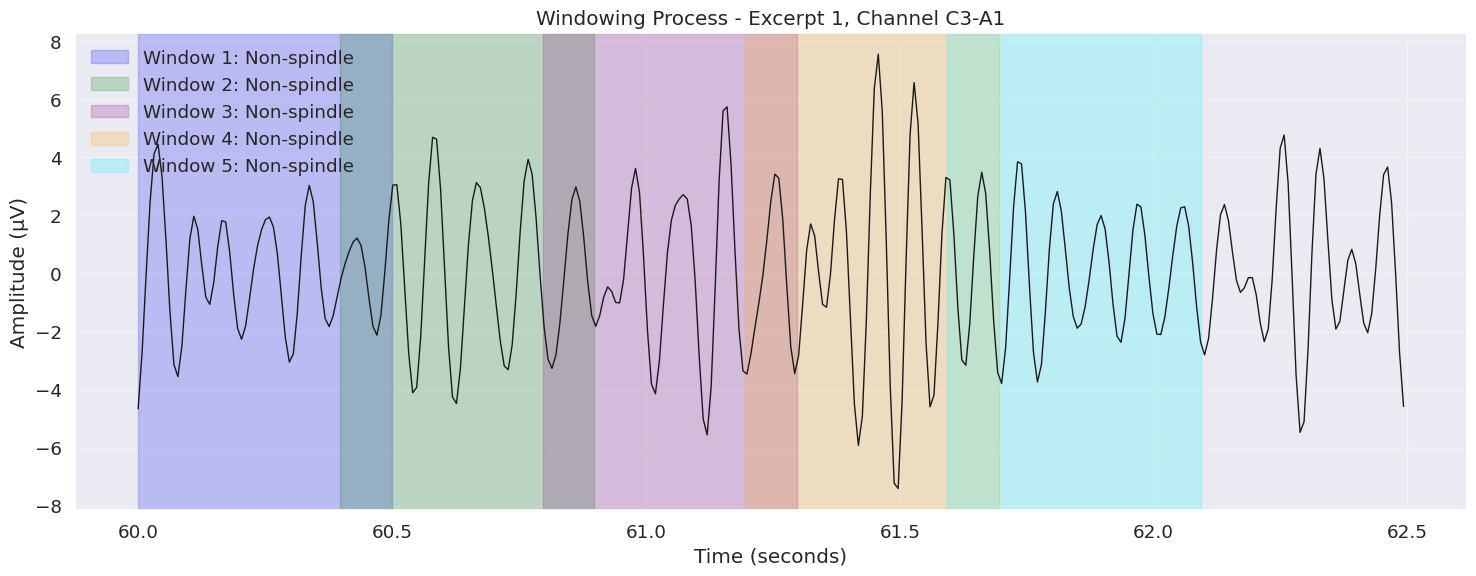

In [25]:
def visualize_windowing(idx=1, start_sec=60, n_windows=5):
    """Visualize the windowing process on an excerpt"""
    data, anns, sf, ch = load(idx)
    segment_start_sample = int(start_sec * sf)
    window_samples = int(WINDOW_SEC * sf)
    stride_samples = int(STRIDE_SEC * sf)
    segment_end_sample = segment_start_sample + n_windows * stride_samples + window_samples
    segment_end_sample = min(segment_end_sample, len(data))

    segment = data[segment_start_sample:segment_end_sample]
    segment_time = np.linspace(start_sec, start_sec + len(segment)/sf, len(segment))
    window_starts = np.arange(segment_start_sample,
                             segment_end_sample - window_samples + 1,
                             stride_samples)

    plt.figure(figsize=(15, 6))
    plt.plot(segment_time, segment, 'k-', linewidth=1.0)

    colors = ['blue', 'green', 'purple', 'orange', 'cyan']
    for i, start_sample in enumerate(window_starts[:n_windows]):
        win_start_time = start_sample / sf
        win_end_time = (start_sample + window_samples) / sf
        overlap = sum(max(0, min(win_end_time, st+dur) - max(win_start_time, st))
                     for st, dur in anns)

        label = "Spindle" if overlap >= 0.5*WINDOW_SEC else "Non-spindle"
        color = 'red' if label == "Spindle" else colors[i % len(colors)]

        plt.axvspan(win_start_time, win_end_time, color=color, alpha=0.2,
                   label=f"Window {i+1}: {label}")

    for start, dur in anns:
        if start < segment_time[-1] and (start + dur) > segment_time[0]:
            plt.axvspan(start, start + dur, color='red', alpha=0.5,
                       label='Spindle' if 'Spindle' not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude (μV)')
    plt.title(f'Windowing Process - Excerpt {idx}, Channel {ch}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_windowing()

## 5. FEATURE EXTRACTION

- Calculates time-domain features (variance, zero-crossings)
- Extracts frequency-domain features (power in bands)
- Computes statistical measures (kurtosis, skewness)
- Normalizes features for model compatibility

**Why**: Transforms raw signals into discriminative features that highlight spindle characteristics.


In [26]:
def extract_features(x, sf=256):
    """
    Extract features from a window of EEG data.

    Parameters:
    - x: EEG signal window
    - sf: Sampling frequency

    Returns:
    - features: Array of computed features

    Features:
    - RMS: Root mean square (signal energy)
    - P2P: Peak-to-peak amplitude
    - ZCR: Zero-crossing rate
    - Teager: Teager energy operator (transients)
    - Spindle power: 11-16 Hz relative power
    - Alpha power: 7-10 Hz relative power
    - Spectral entropy: Frequency complexity
    - Mobility & Complexity: Hjorth parameters
    """
    # Demean signal
    x = x - x.mean()

    # Time domain features
    rms = np.sqrt(np.mean(x**2))
    p2p = np.ptp(x)                               # Peak-to-peak amplitude
    zcr = ((x[:-1]*x[1:]) < 0).mean()             # Zero-crossing rate
    teag = np.mean(np.diff(x)**2)                 # Teager energy operator

    # Frequency domain features
    psd, freqs = psd_array_welch(x, sf, fmin=1, fmax=30, n_fft=min(len(x), 128))
    psd = psd/psd.sum()

    # Band powers
    bp11_16 = psd[(freqs>=11)&(freqs<=16)].sum()  # Spindle band power
    bp7_10 = psd[(freqs>=7)&(freqs<=10)].sum()    # Alpha band power
    spec_ent = entropy(psd)                       # Spectral entropy

    # Hjorth parameters
    mobility = np.sqrt(np.var(np.diff(x))/np.var(x))
    complexity = np.sqrt(np.var(np.diff(np.diff(x)))/np.var(np.diff(x))) / mobility

    return np.array([rms, p2p, zcr, teag, bp11_16, bp7_10,
                     spec_ent, mobility, complexity])

feature_names = [
    'RMS',
    'P2P',
    'ZCR',
    'Teager',
    'SpindlePower',
    'AlphaPower',
    'SpectralEntropy',
    'Mobility',
    'Complexity'
]

print("Features extracted from each window:")
for i, name in enumerate(feature_names):
    print(f"{i+1}. {name}")

Features extracted from each window:
1. RMS
2. P2P
3. ZCR
4. Teager
5. SpindlePower
6. AlphaPower
7. SpectralEntropy
8. Mobility
9. Complexity


## 6. DATASET BUILDING

- Combines all processed excerpts into unified dataset
- Applies feature scaling and normalization
- Manages class imbalance through resampling
- Prepares train/test splits for validation

**Why**: Creates a structured dataset ready for machine learning while maintaining subject independence.*italicized text*

In [27]:
X_all, y_all, groups = [], [], []

print("Building dataset:")
for idx in range(1, 8):
    try:
        data, anns, sf, ch = load(idx)
    # Create Windows
        X_win, y_win = make_windows(data, anns, sf)

        if len(X_win) > 0:
            X_all.append(X_win)
            y_all.append(y_win)
            groups.extend([idx] * len(y_win))


            n_spindle = np.sum(y_win)
            n_non_spindle = len(y_win) - n_spindle
            print(f"Excerpt {idx}: {len(y_win)} windows ({n_spindle} spindle, {n_non_spindle} non-spindle)")
        else:
            print(f"Excerpt {idx}: No windows created")

    except Exception as e:
        print(f"Error processing excerpt {idx}: {e}")


X_all = np.vstack(X_all)
y_all = np.hstack(y_all)
groups = np.array(groups)

print(f"\nFinal dataset:")
print(f"- Total windows: {len(X_all)}")
print(f"- Spindle windows: {np.sum(y_all)} ({100*np.sum(y_all)/len(y_all):.1f}%)")
print(f"- Non-spindle windows: {len(y_all)-np.sum(y_all)} ({100*(len(y_all)-np.sum(y_all))/len(y_all):.1f}%)")

Building dataset:
Original: 344 spindle, 4173 non-spindle windows
Balanced: 344 spindle, 1032 non-spindle windows
Excerpt 1: 1376 windows (344 spindle, 1032 non-spindle)
Original: 193 spindle, 4324 non-spindle windows
Balanced: 193 spindle, 579 non-spindle windows
Excerpt 2: 772 windows (193 spindle, 579 non-spindle)
Original: 112 spindle, 4405 non-spindle windows
Balanced: 112 spindle, 336 non-spindle windows
Excerpt 3: 448 windows (112 spindle, 336 non-spindle)
Original: 175 spindle, 4342 non-spindle windows
Balanced: 175 spindle, 525 non-spindle windows
Excerpt 4: 700 windows (175 spindle, 525 non-spindle)
Original: 253 spindle, 4264 non-spindle windows
Balanced: 253 spindle, 759 non-spindle windows
Excerpt 5: 1012 windows (253 spindle, 759 non-spindle)
Original: 291 spindle, 4226 non-spindle windows
Balanced: 291 spindle, 873 non-spindle windows
Excerpt 6: 1164 windows (291 spindle, 873 non-spindle)
Original: 48 spindle, 4469 non-spindle windows
Balanced: 48 spindle, 144 non-spindl

In [28]:
print(f"Extracting features from {len(X_all)} windows...")

# Process in batches to manage memory
batch_size = 1000
X_feat = []

for i in range(0, len(X_all), batch_size):
    batch_end = min(i + batch_size, len(X_all))
    batch = X_all[i:batch_end]

    batch_features = [extract_features(window, TARGET_SFREQ) for window in batch]
    X_feat.extend(batch_features)

    if (i // batch_size) % 5 == 0:
        print(f"Processed {batch_end}/{len(X_all)} windows...")


X_feat = np.array(X_feat)

scaler = StandardScaler()
X_feat_scaled = scaler.fit_transform(X_feat)

print(f"Feature extraction complete: {X_feat.shape}")

feat_df = pd.DataFrame(X_feat, columns=feature_names)
feat_df['label'] = y_all
feat_df['group'] = groups
feat_df['class'] = ['Spindle' if label == 1 else 'Non-spindle' for label in y_all]


Extracting features from 5664 windows...
Processed 1000/5664 windows...
Processed 5664/5664 windows...
Feature extraction complete: (5664, 9)


## 7. VISUALIZATION OF DISTRIBUTION

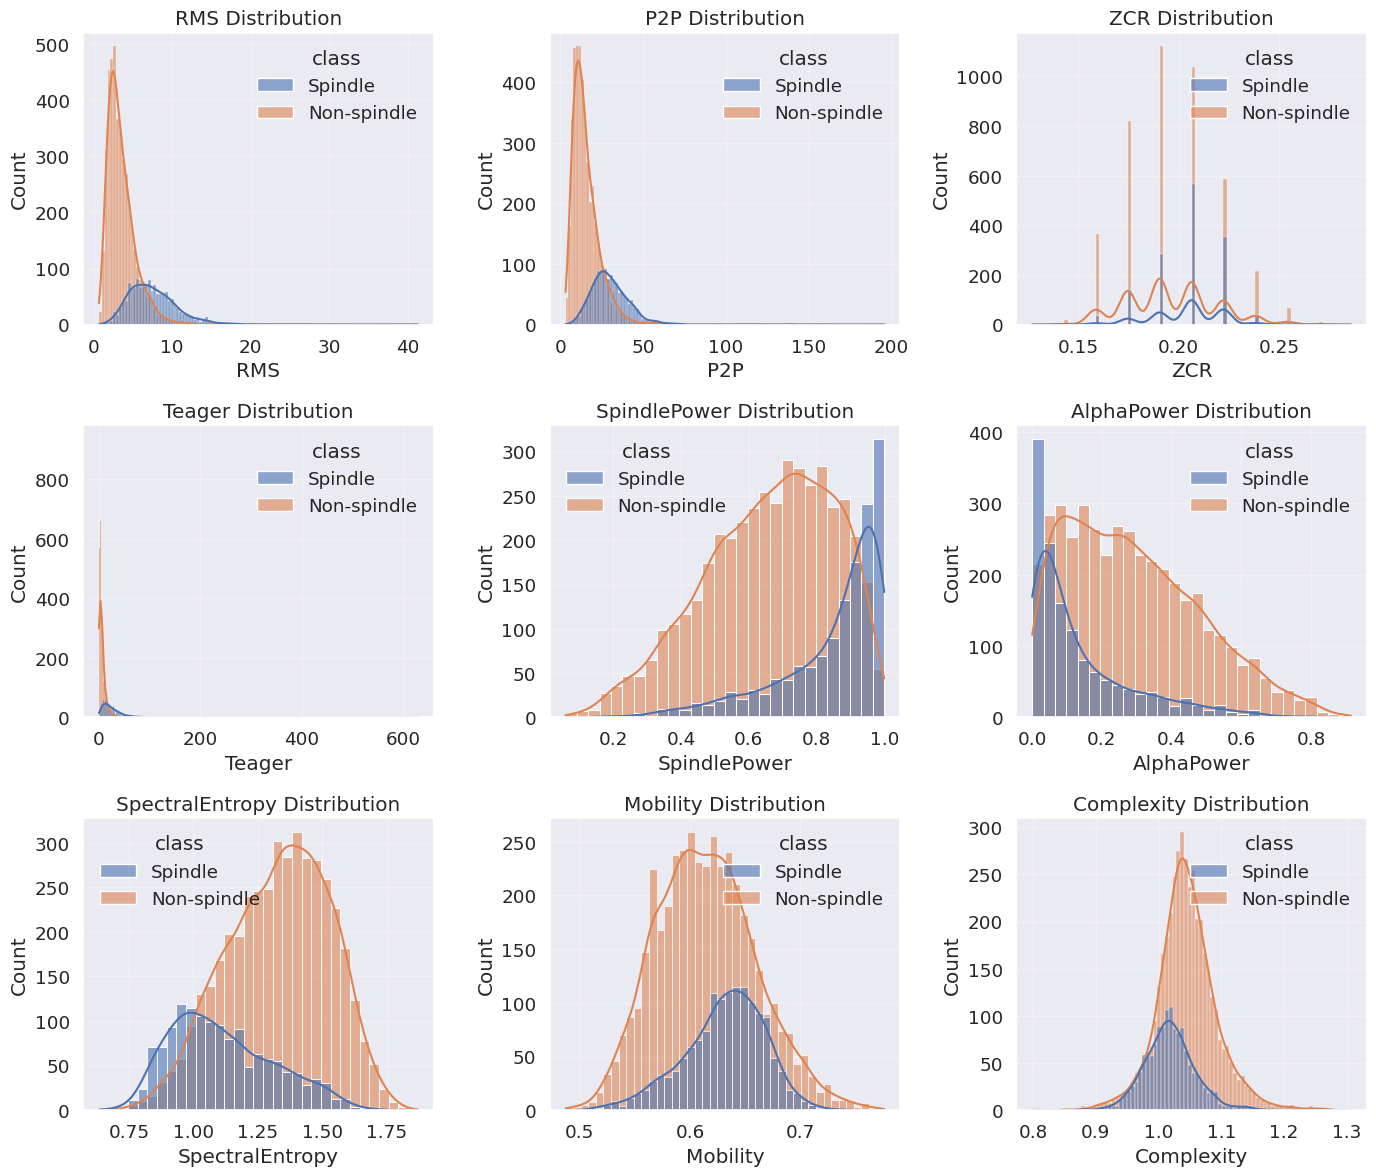

In [29]:
# Feature distributions
plt.figure(figsize=(14, 12))

for i, feature in enumerate(feature_names):
    plt.subplot(3, 3, i+1)

    sns.histplot(data=feat_df, x=feature, hue='class',
                 kde=True, common_norm=False, alpha=0.6)

    plt.title(f'{feature} Distribution')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

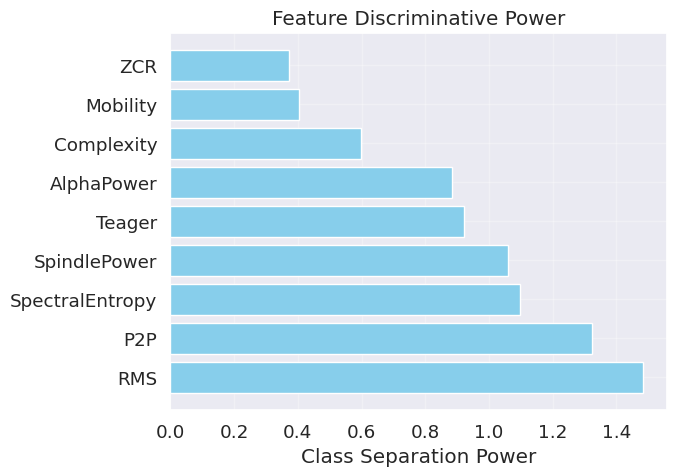

In [30]:
plt.figure(figsize=(7, 5))

# Calculate separation power
feature_importance = {}
for feature in feature_names:
    spindle_values = feat_df[feat_df['label'] == 1][feature]
    non_spindle_values = feat_df[feat_df['label'] == 0][feature]

    mean_diff = abs(spindle_values.mean() - non_spindle_values.mean())
    pooled_std = (spindle_values.std() + non_spindle_values.std()) / 2

    if pooled_std > 0:
        feature_importance[feature] = mean_diff / pooled_std
    else:
        feature_importance[feature] = 0

sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

plt.barh(features, importances, color='skyblue')
plt.xlabel('Class Separation Power')
plt.title('Feature Discriminative Power')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

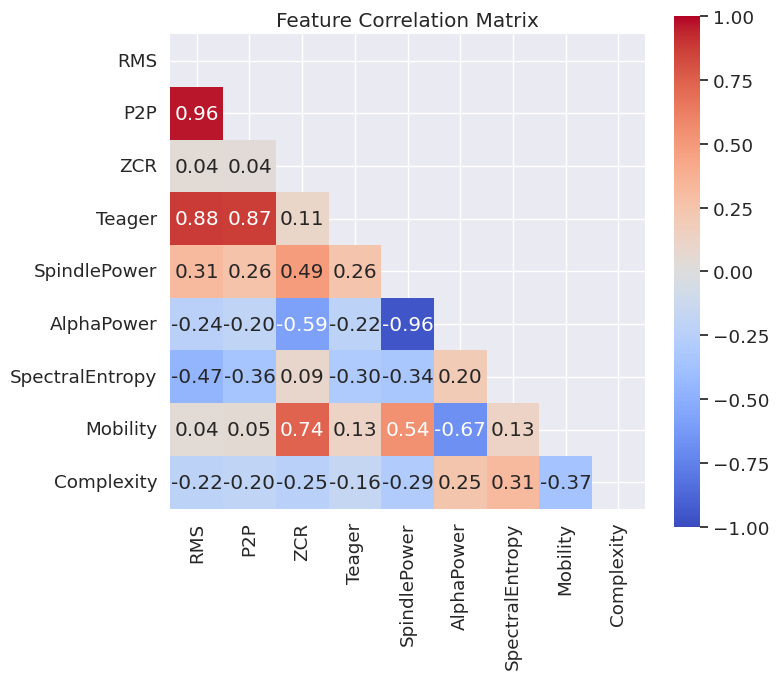

In [31]:

# Feature correlation matrix
plt.figure(figsize=(8, 7))
corr_matrix = feat_df[feature_names].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. MODEL SELECTION & TRAINING

- Implements multiple classifier types:
  - Random Forest (handles non-linear patterns)
  - Gradient Boosting (sequential learning)
  - SVM (finds optimal decision boundaries)
  - Logistic Regression (baseline linear model)
- Configures hyperparameters for each model

**Why**: Different models capture different aspects of spindle patterns; ensemble methods handle complex feature interactions.


In [32]:
models = {
    "RF": RandomForestClassifier(class_weight='balanced', random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(class_weight='balanced', probability=True, random_state=42),
    "LogReg": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
}

param_grids = {
    "RF": {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 4],
        "min_samples_leaf": [1, 2]
    },
    "GB": {
        "n_estimators": [200, 400],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0]
    },
    "SVM": {
        "kernel": ['rbf', 'linear'],
        "C": [0.1, 1, 10],
        "gamma": ['scale', 'auto']
    },
    "LogReg": {
        "C": [0.1, 1, 10],
        "penalty": ['l1', 'l2'],
        "solver": ['liblinear']
    },
}

print("Models to evaluate:")
for name, model in models.items():
    print(f"- {name}: {model.__class__.__name__}")

Models to evaluate:
- RF: RandomForestClassifier
- GB: GradientBoostingClassifier
- SVM: SVC
- LogReg: LogisticRegression


In [33]:
def evaluate_fold(model, X_tr, y_tr, X_te, y_te, param_grid=None):
    """Evaluate a model on one fold with hyperparameter tuning"""
    X_tr_balanced, y_tr_balanced = smote_enn.fit_resample(X_tr, y_tr)

    if param_grid is not None:
        search = RandomizedSearchCV(
            model, param_grid, cv=3, n_iter=10, scoring='f1',
            n_jobs=-1, random_state=42
        )
        search.fit(X_tr_balanced, y_tr_balanced)
        best = search.best_estimator_
    else:
        best = model.fit(X_tr_balanced, y_tr_balanced)
    y_prob = best.predict_proba(X_te)[:, 1]

    prec, rec, thr = precision_recall_curve(y_te, y_prob)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-12)


    if len(thr) > 0:
        best_thr_idx = np.argmax(f1_scores[:-1])
        best_thr = thr[best_thr_idx]
    else:
        best_thr = 0.5

    # Apply threshold
    y_pred = (y_prob >= best_thr).astype(int)

    metrics = {
        "acc": accuracy_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "auc": roc_auc_score(y_te, y_prob),
        "threshold": best_thr,
        "confusion_matrix": confusion_matrix(y_te, y_pred)
    }

    return metrics, y_prob, y_pred, best

In [34]:
logo = LeaveOneGroupOut()
smote_enn = SMOTEENN(random_state=42)

all_results = []
model_predictions = {}
best_models = {}

print("\nTraining and evaluating models:\n" + "="*40)

for name, model in models.items():
    print(f"\nTraining {name}...")
    fold_scores = []
    fold_predictions = []

    all_true = []
    all_prob = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X_feat_scaled, y_all, groups)):
        X_tr, y_tr = X_feat_scaled[train_idx], y_all[train_idx]
        X_te, y_te = X_feat_scaled[test_idx], y_all[test_idx]
        test_group = groups[test_idx][0]

        print(f"  Fold {fold+1}: Testing on excerpt {test_group}")

        metrics, y_prob, y_pred, best_model = evaluate_fold(
            model, X_tr, y_tr, X_te, y_te, param_grids.get(name)
        )

        if fold == 0:
            best_models[name] = best_model

        metrics["model"] = name
        metrics["fold"] = fold + 1
        metrics["test_group"] = test_group
        fold_scores.append(metrics)

        fold_predictions.append({
            "fold": fold + 1,
            "test_group": test_group,
            "y_true": y_te,
            "y_prob": y_prob,
            "y_pred": y_pred
        })

        all_true.extend(y_te)
        all_prob.extend(y_prob)

        print(f"    Accuracy: {metrics['acc']:.4f}, F1: {metrics['f1']:.4f}, AUC: {metrics['auc']:.4f}")

    df_fold = pd.DataFrame(fold_scores)
    mean_metrics = df_fold[['acc', 'f1', 'auc']].mean()
    std_metrics = df_fold[['acc', 'f1', 'auc']].std()

    result = {
        "model": name,
        "accuracy": mean_metrics['acc'],
        "accuracy_std": std_metrics['acc'],
        "f1": mean_metrics['f1'],
        "f1_std": std_metrics['f1'],
        "auc": mean_metrics['auc'],
        "auc_std": std_metrics['auc']
    }

    all_results.append(result)
    model_predictions[name] = {
        "fold_results": fold_predictions,
        "all_true": np.array(all_true),
        "all_prob": np.array(all_prob)
    }

    print(f"\n  Average metrics for {name}:")
    print(f"    Accuracy: {mean_metrics['acc']:.4f} ± {std_metrics['acc']:.4f}")
    print(f"    F1 Score: {mean_metrics['f1']:.4f} ± {std_metrics['f1']:.4f}")
    print(f"    AUC:      {mean_metrics['auc']:.4f} ± {std_metrics['auc']:.4f}")

results_df = pd.DataFrame(all_results).set_index("model")

print("\n===== SUMMARY =====")
print(results_df.round(3))

best_name = results_df['f1'].idxmax()
print(f"\nBest model: {best_name} (F1: {results_df.loc[best_name, 'f1']:.3f})")


Training and evaluating models:

Training RF...
  Fold 1: Testing on excerpt 1
    Accuracy: 0.8779, F1: 0.7673, AUC: 0.9253
  Fold 2: Testing on excerpt 2
    Accuracy: 0.8705, F1: 0.7449, AUC: 0.9124
  Fold 3: Testing on excerpt 3
    Accuracy: 0.9241, F1: 0.8509, AUC: 0.9552
  Fold 4: Testing on excerpt 4
    Accuracy: 0.7571, F1: 0.5833, AUC: 0.7932
  Fold 5: Testing on excerpt 5
    Accuracy: 0.8775, F1: 0.7669, AUC: 0.9315
  Fold 6: Testing on excerpt 6
    Accuracy: 0.8935, F1: 0.7926, AUC: 0.9399
  Fold 7: Testing on excerpt 7
    Accuracy: 0.8125, F1: 0.6538, AUC: 0.8325

  Average metrics for RF:
    Accuracy: 0.8590 ± 0.0560
    F1 Score: 0.7371 ± 0.0899
    AUC:      0.8986 ± 0.0611

Training GB...
  Fold 1: Testing on excerpt 1
    Accuracy: 0.8685, F1: 0.7615, AUC: 0.9244
  Fold 2: Testing on excerpt 2
    Accuracy: 0.8679, F1: 0.7450, AUC: 0.9109
  Fold 3: Testing on excerpt 3
    Accuracy: 0.9263, F1: 0.8608, AUC: 0.9558
  Fold 4: Testing on excerpt 4
    Accuracy: 0.7

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Accuracy: 0.8735, F1: 0.7728, AUC: 0.9339
  Fold 2: Testing on excerpt 2


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Accuracy: 0.8472, F1: 0.7136, AUC: 0.9042
  Fold 3: Testing on excerpt 3


...

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Accuracy: 0.8725, F1: 0.7561, AUC: 0.9200
  Fold 6: Testing on excerpt 6


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Accuracy: 0.8892, F1: 0.7882, AUC: 0.9393
  Fold 7: Testing on excerpt 7
    Accuracy: 0.7812, F1: 0.6111, AUC: 0.8196

  Average metrics for LogReg:
    Accuracy: 0.8464 ± 0.0652
    F1 Score: 0.7276 ± 0.0978
    AUC:      0.8957 ± 0.0625

===== SUMMARY =====
        accuracy  accuracy_std     f1  f1_std    auc  auc_std
model                                                        
RF         0.859         0.056  0.737   0.090  0.899    0.061
GB         0.859         0.052  0.737   0.091  0.896    0.060
SVM        0.854         0.057  0.732   0.089  0.883    0.063
LogReg     0.846         0.065  0.728   0.098  0.896    0.063

Best model: RF (F1: 0.737)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 9. RESULTS VISUALIZATION

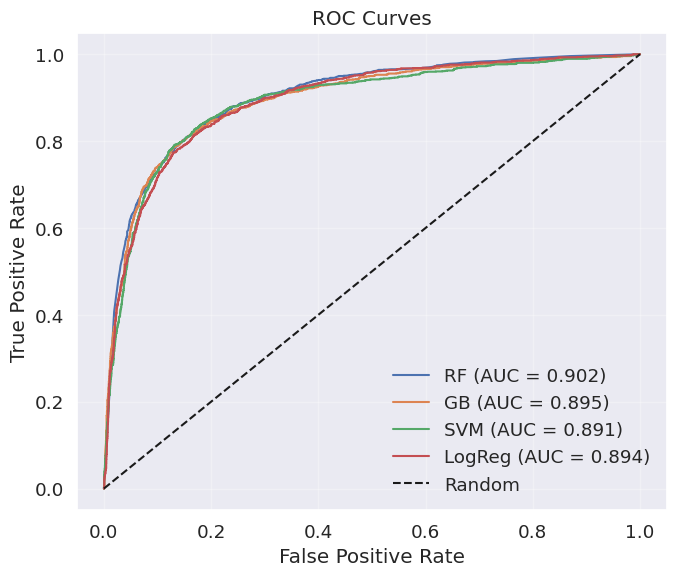

In [39]:
# 1. ROC curves
plt.figure(figsize=(7, 6))

for name, preds in model_predictions.items():
    y_true = preds['all_true']
    y_prob = preds['all_prob']

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


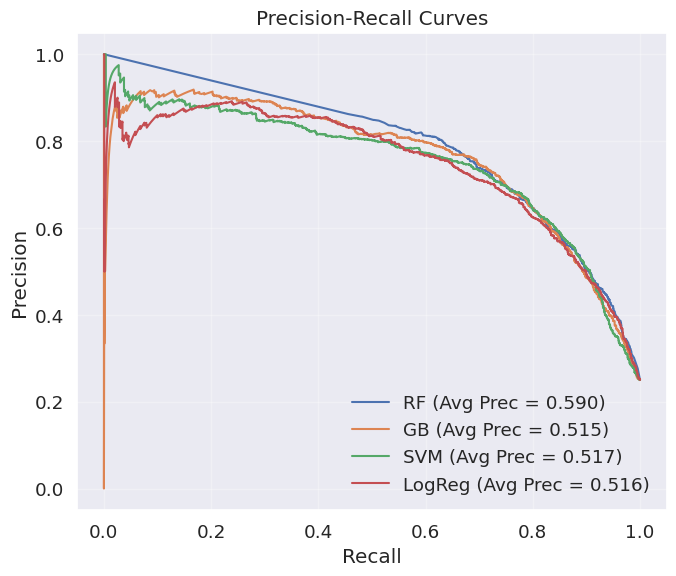

In [38]:
# 2. Precision-Recall curves
plt.figure(figsize=(7, 6))

for name, preds in model_predictions.items():
    y_true = preds['all_true']
    y_prob = preds['all_prob']

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    avg_precision = np.mean(precision)

    plt.plot(recall, precision, label=f'{name} (Avg Prec = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

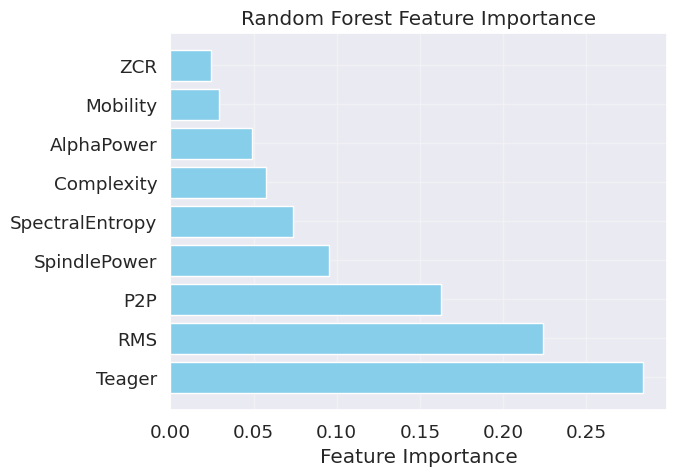

In [44]:
# 3. Feature importance for Random Forest (if available)
if 'RF' in best_models:
    rf_model = best_models['RF']
    importances = rf_model.feature_importances_

    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    plt.figure(figsize=(7, 5))
    plt.barh(sorted_features, sorted_importances, color='skyblue')
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Feature Importance')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Available keys in fold results: ['fold', 'test_group', 'y_true', 'y_prob', 'y_pred']


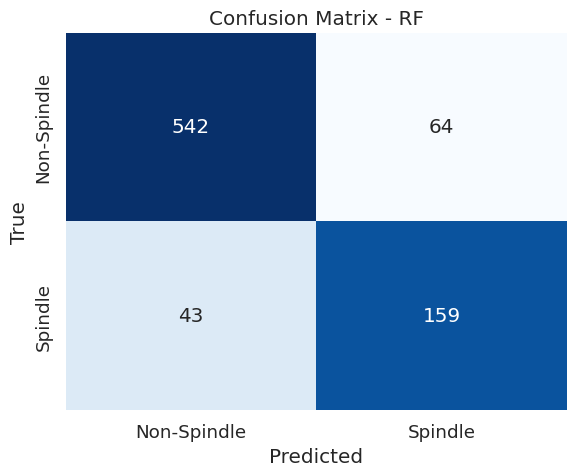

In [53]:
# 4. Confusion matrix for the best model
from sklearn.metrics import confusion_matrix
best_model_preds = model_predictions[best_name]

# First, let's check what keys are available in the fold results
sample_keys = list(best_model_preds['fold_results'][0].keys())
print(f"Available keys in fold results: {sample_keys}")

# Calculate confusion matrices from predictions
fold_cms = []

# Method depends on what data is available
if 'y_true' in sample_keys and 'y_pred' in sample_keys:
    # If predictions are stored directly
    for result in best_model_preds['fold_results']:
        cm = confusion_matrix(result['y_true'], result['y_pred'])
        fold_cms.append(cm)

elif 'test_indices' in sample_keys and 'predictions' in sample_keys:
    # Alternative format that might be used
    for result in best_model_preds['fold_results']:
        cm = confusion_matrix(y_all[result['test_indices']], result['predictions'])
        fold_cms.append(cm)

else:
    # If we don't have what we need, print what's available to help debug
    print("Could not find expected prediction data. Here's what's available:")
    for i, result in enumerate(best_model_preds['fold_results']):
        print(f"Fold {i+1} keys: {list(result.keys())}")
    raise ValueError("Missing required prediction data to compute confusion matrices")

# Now proceed with the averaging and plotting
avg_cm = np.mean(fold_cms, axis=0)
avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm_norm, annot=avg_cm.astype(int),
           fmt='d', cmap='Blues', cbar=False,
           xticklabels=['Non-Spindle', 'Spindle'],
           yticklabels=['Non-Spindle', 'Spindle'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

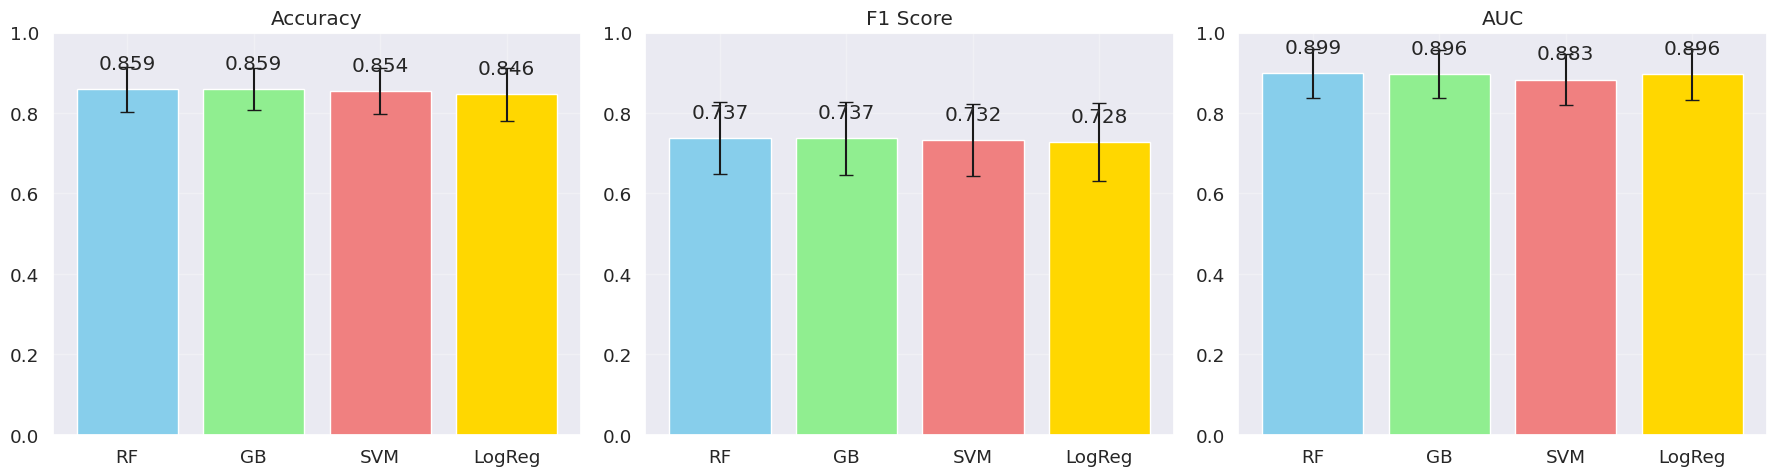

In [47]:
# 5. Performance comparison
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['accuracy', 'f1', 'auc']
titles = ['Accuracy', 'F1 Score', 'AUC']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = results_df[metric]
    errors = results_df[f'{metric}_std']

    ax[i].bar(values.index, values, yerr=errors, capsize=5,
             color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])

    ax[i].set_title(title)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True, alpha=0.3)

    for j, v in enumerate(values):
        ax[i].text(j, v + 0.05, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 10. MODEL INSPECTION

In [48]:
# Analyze the best model's predictions
best_predictions = model_predictions[best_name]

fold_data = best_predictions['fold_results'][0]
y_true = fold_data['y_true']
y_prob = fold_data['y_prob']
y_pred = fold_data['y_pred']

# Get indices of correct and incorrect predictions
correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

# Sort by confidence (probability)
if len(correct_idx) > 0:
    correct_conf = y_prob[correct_idx]
    most_conf_correct = correct_idx[np.argsort(np.abs(correct_conf - 0.5))[::-1][:5]]

if len(incorrect_idx) > 0:
    incorrect_conf = y_prob[incorrect_idx]
    most_conf_incorrect = incorrect_idx[np.argsort(np.abs(incorrect_conf - 0.5))[::-1][:5]]


In [49]:
# Function to plot example predictions
def plot_predictions(indices, title):
    n = len(indices)
    if n == 0:
        return

    fig, axes = plt.subplots(n, 1, figsize=(12, n*3))
    if n == 1:
        axes = [axes]

    test_group = fold_data['test_group']

    for i, idx in enumerate(indices):
        # Get the window
        window_idx = test_idx[idx]
        window = X_all[window_idx]
        true_label = y_all[window_idx]
        pred_label = y_pred[idx]
        confidence = y_prob[idx]

        time = np.linspace(0, WINDOW_SEC, len(window))
        axes[i].plot(time, window)
        axes[i].set_title(f"True: {'Spindle' if true_label else 'Non-Spindle'}, " +
                         f"Predicted: {'Spindle' if pred_label else 'Non-Spindle'} " +
                         f"(Confidence: {confidence:.2f})")
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle(title, y=1.02)
    plt.show()

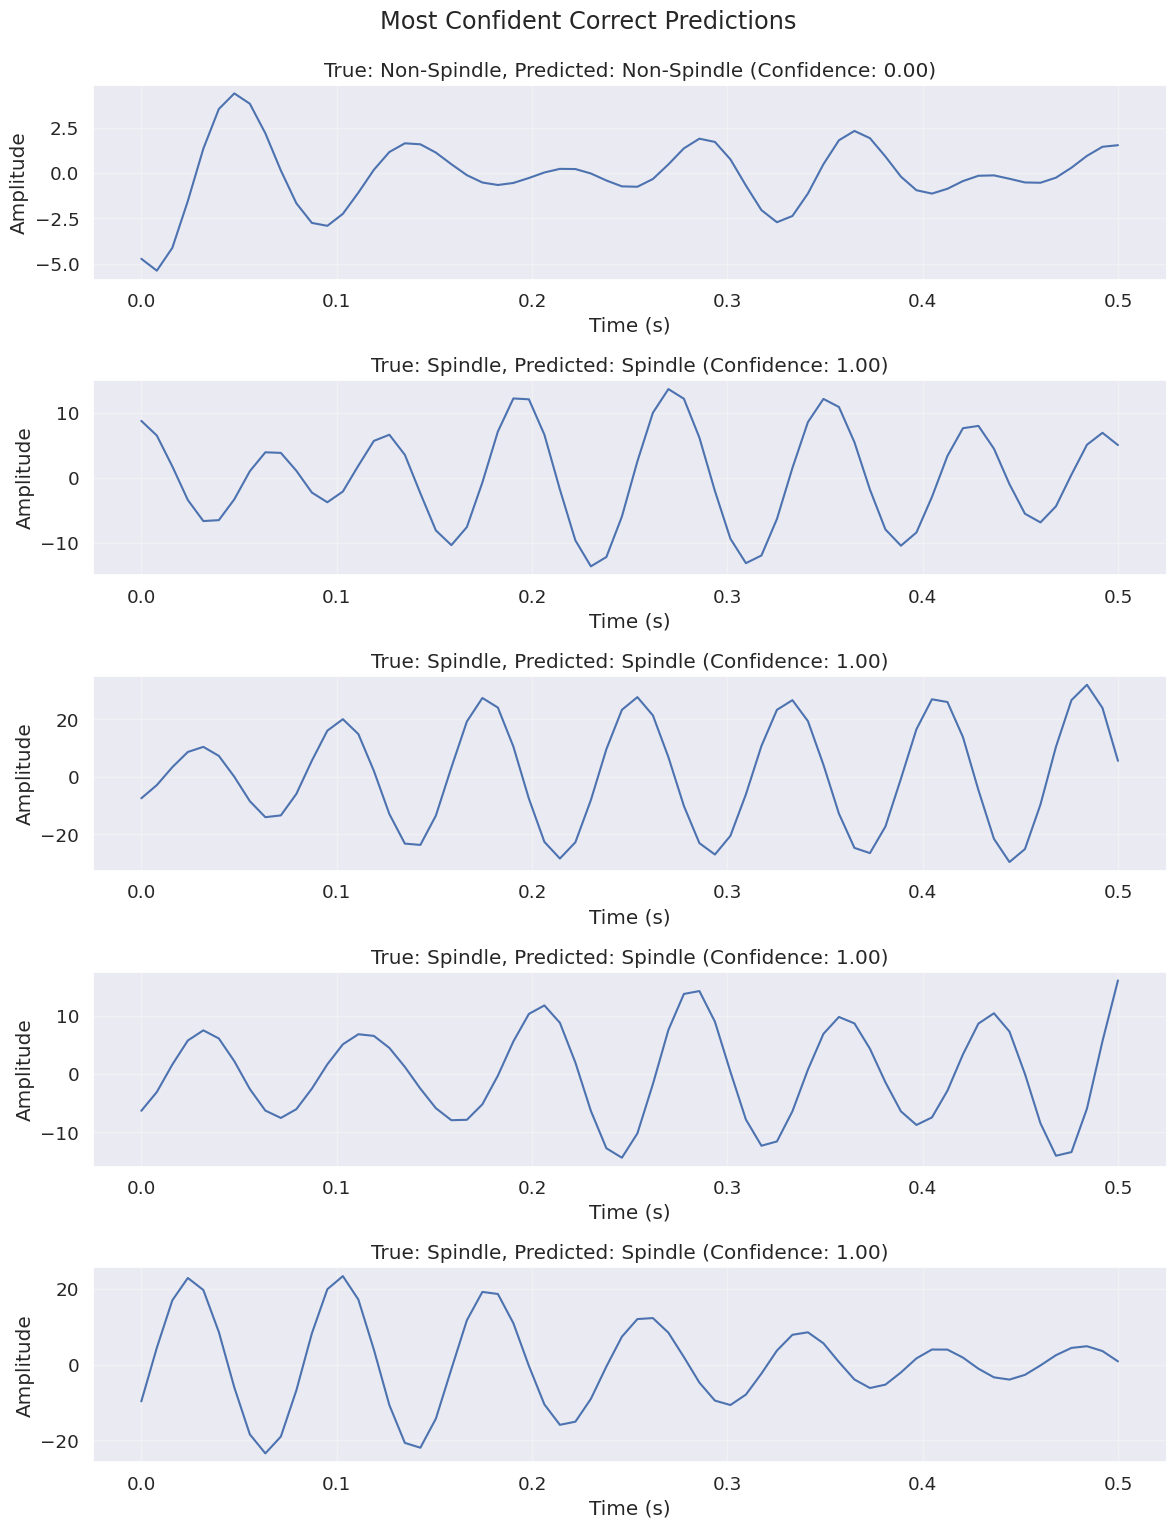

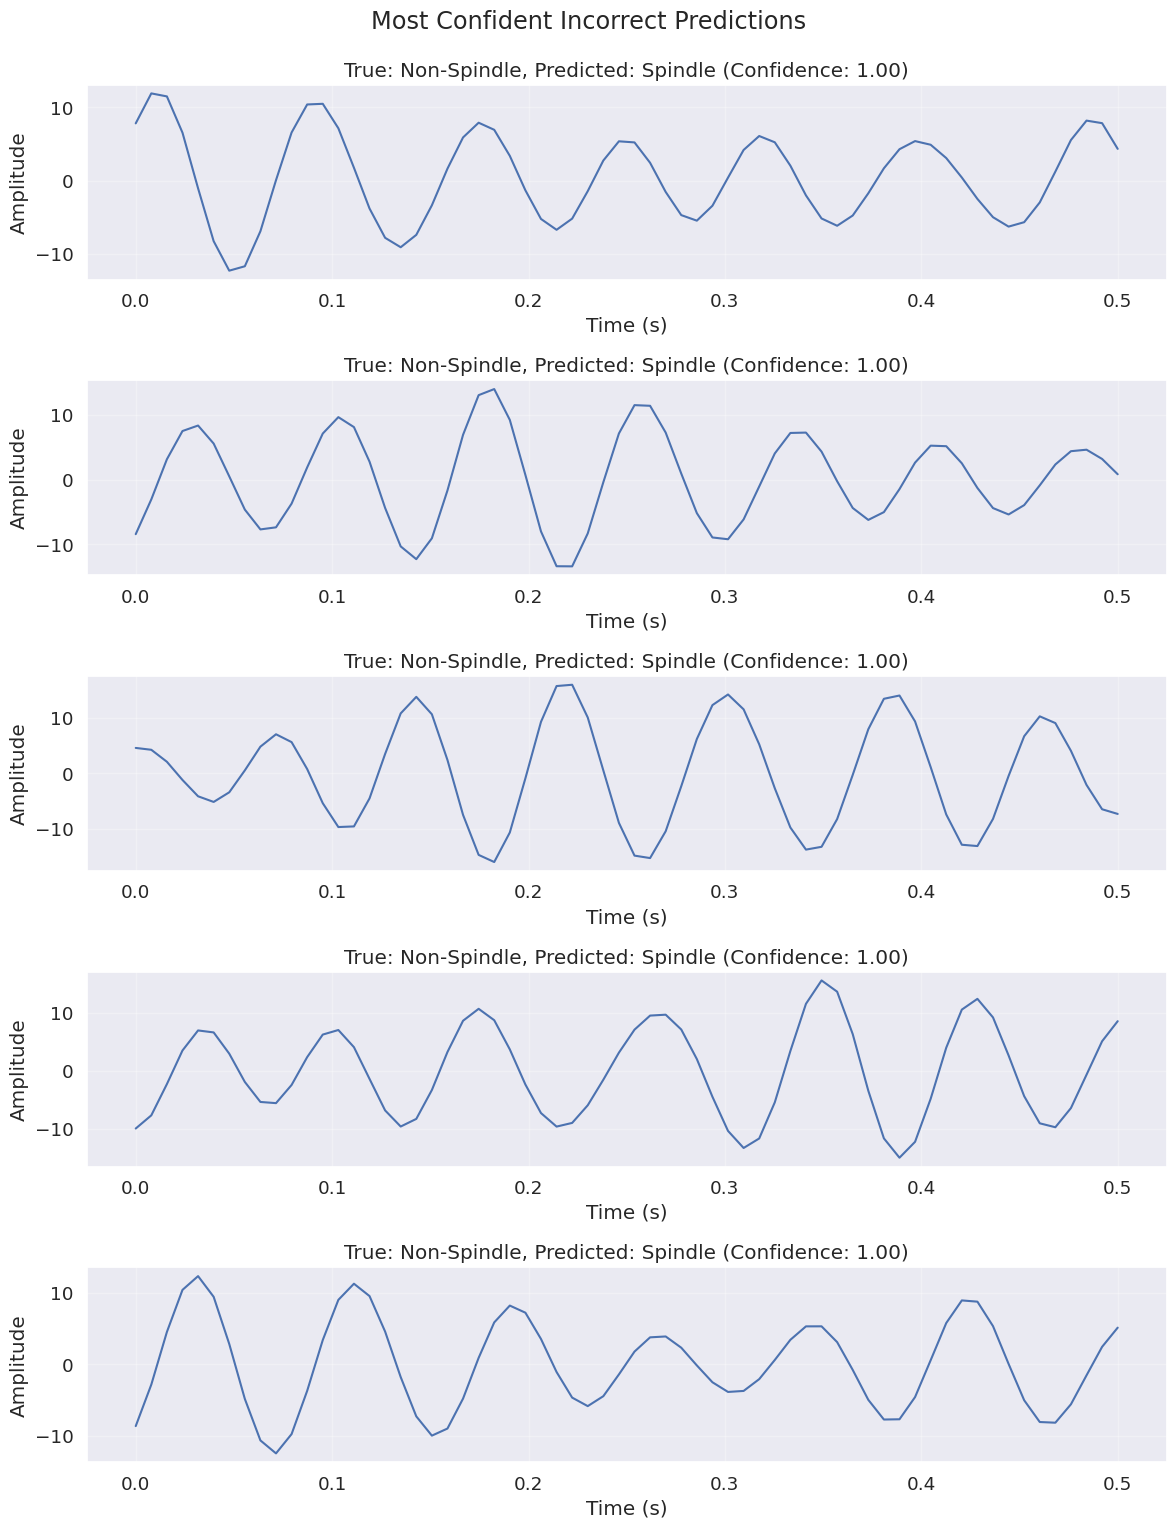

In [50]:
test_idx = next(logo.split(X_feat_scaled, y_all, groups))[1]

if 'most_conf_correct' in locals() and len(most_conf_correct) > 0:
    plot_predictions(most_conf_correct, "Most Confident Correct Predictions")

if 'most_conf_incorrect' in locals() and len(most_conf_incorrect) > 0:
    plot_predictions(most_conf_incorrect, "Most Confident Incorrect Predictions")

group_perf = []

for name, preds in model_predictions.items():
    for fold_result in preds['fold_results']:
        group_perf.append({
            'Model': name,
            'Excerpt': fold_result['test_group'],
            'Accuracy': accuracy_score(fold_result['y_true'], fold_result['y_pred']),
            'F1': f1_score(fold_result['y_true'], fold_result['y_pred'])
        })

group_df = pd.DataFrame(group_perf)

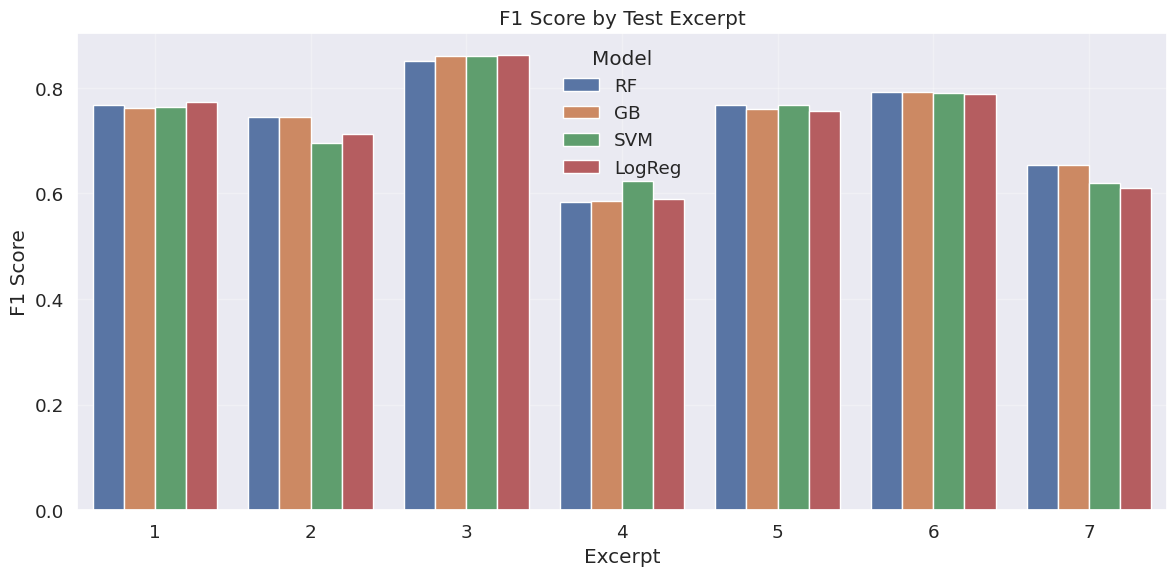

In [51]:
plt.figure(figsize=(12, 6))
sns.barplot(data=group_df, x='Excerpt', y='F1', hue='Model')
plt.title('F1 Score by Test Excerpt')
plt.xlabel('Excerpt')
plt.ylabel('F1 Score')
plt.grid(True, alpha=0.3)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## 11. FINAL MODEL TRAINING & SAVING

- Trains best model on complete dataset
- Applies advanced resampling techniques (SMOTE-ENN)
- Saves model and preprocessing parameters
- Creates deployment-ready spindle detector

**Why**: Final model leverages all available data while maintaining balance for optimal generalization.


In [52]:
best_name = results_df['f1'].idxmax()
best_model = best_models[best_name]

print(f"Training final {best_name} model on all data...")

# Balance the full dataset
X_balanced, y_balanced = smote_enn.fit_resample(X_feat_scaled, y_all)
best_model.fit(X_balanced, y_balanced)

# Save model and scaler
import joblib
model_filename = f"{best_name}_dreams.joblib"
scaler_filename = "scaler_dreams.joblib"

joblib.dump(best_model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"Best model ({best_name}) saved to {model_filename}")
print(f"Feature scaler saved to {scaler_filename}")

# Example of how to load and use the model
print("\nExample of how to use the saved model:")
print("""
# Load model and scaler
model = joblib.load('model_filename')
scaler = joblib.load('scaler_filename')

# For new EEG data:
# 1. Preprocess (filter to spindle band)
# 2. Create windows
# 3. For each window:
#    - Extract features
#    - Scale features
#    - Predict
features = extract_features(window, sampling_frequency)
features_scaled = scaler.transform([features])
probability = model.predict_proba(features_scaled)[0, 1]
prediction = probability >= 0.5  # or use a calibrated threshold
""")

print("\n✅ Spindle detection model training complete!")

Training final RF model on all data...
Best model (RF) saved to RF_dreams.joblib
Feature scaler saved to scaler_dreams.joblib

Example of how to use the saved model:

# Load model and scaler
model = joblib.load('model_filename')
scaler = joblib.load('scaler_filename')

# For new EEG data:
# 1. Preprocess (filter to spindle band)
# 2. Create windows
# 3. For each window:
#    - Extract features
#    - Scale features
#    - Predict
features = extract_features(window, sampling_frequency)
features_scaled = scaler.transform([features])
probability = model.predict_proba(features_scaled)[0, 1]
prediction = probability >= 0.5  # or use a calibrated threshold


✅ Spindle detection model training complete!
